In [1]:
# Initialize libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

os.chdir('/home/kaseng/warehouse/data/')

In [42]:
# Load data
comp_trial_1 = np.load("./composite_trial_2.npy")
separate_trial_1 = np.load("./separate_trial_1.npy") # closer to pure CBF, will redo
separate_trial_3 = np.load("./separate_trial_3.npy") # most tuned for balance

print(comp_trial_1.shape)
print(separate_trial_1.shape)
print(separate_trial_3.shape)

(10000, 3)
(10000, 3)
(10000, 3)


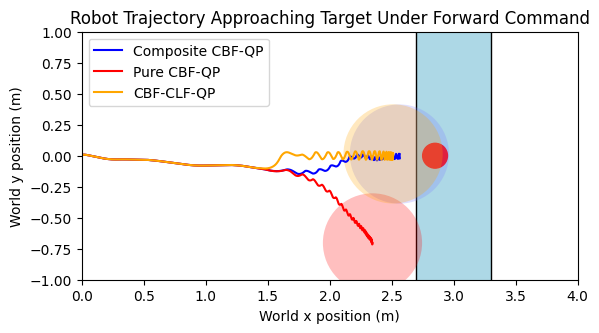

In [45]:
data_threshold = 10000

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor='lightblue')
circle_target = Circle((2.85, 0.0), radius=0.1, edgecolor="red", facecolor="red")
circle_composite = Circle((comp_trial_1[data_threshold-1, :2]), radius=0.4, facecolor=(0.5,0.5,1.0,0.25))
circle_separate_1 = Circle((separate_trial_1[data_threshold-1,:2]), radius=0.4, facecolor=(1, 0, 0, 0.25))
circle_separate_3 = Circle((separate_trial_3[data_threshold-1,:2]), radius=0.4, facecolor=(1.0,0.65,0,0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_composite)
ax.add_patch(circle_separate_1)
ax.add_patch(circle_separate_3)

ax.plot(comp_trial_1[:data_threshold,0], comp_trial_1[:data_threshold,1], color="b", label="Composite CBF-QP")
ax.plot(separate_trial_1[:data_threshold,0], separate_trial_1[:data_threshold,1], color="r", label="Pure CBF-QP")
ax.plot(separate_trial_3[:data_threshold,0], separate_trial_3[:data_threshold,1], color=(1.0,0.65,0), label="CBF-CLF-QP")

ax.set_xlim(0, 4)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Robot Trajectory Approaching Target Under Forward Command')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend()
plt.show()